In [14]:
import matplotlib.pyplot as plt
import pandas as pd
import yaml
import numpy as np
import os
from PIL import Image
import glob
%matplotlib inline

In [15]:
MAP_NAME = "levine_race2"

In [16]:
csv_files = glob.glob(f'outputs/{MAP_NAME}/*.csv', recursive=True)
csv_files = sorted(csv_files)
csv_files

['outputs/levine_race2/traj_race_cl-2026-03-19 21:21:18.171146.csv',
 'outputs/levine_race2/traj_race_cl-2026-03-19 21:46:07.335109.csv',
 'outputs/levine_race2/traj_race_cl-2026-03-20 11:08:26.494344.csv',
 'outputs/levine_race2/traj_race_cl-2026-03-20 11:11:32.820887.csv',
 'outputs/levine_race2/traj_race_cl-2026-03-20 11:12:15.902639.csv',
 'outputs/levine_race2/traj_race_cl-2026-03-20 11:25:12.353319.csv',
 'outputs/levine_race2/traj_race_cl-2026-03-20 11:39:31.506387.csv',
 'outputs/levine_race2/traj_race_cl-2026-03-20 11:43:05.122845.csv',
 'outputs/levine_race2/traj_race_cl-2026-03-20 11:51:09.547256.csv',
 'outputs/levine_race2/traj_race_cl-2026-03-20 11:54:56.020930.csv',
 'outputs/levine_race2/traj_race_cl-2026-03-20 11:57:15.812549.csv',
 'outputs/levine_race2/traj_race_cl-2026-03-20 11:58:43.704422.csv',
 'outputs/levine_race2/traj_race_cl-2026-03-20 11:59:47.138406.csv',
 'outputs/levine_race2/traj_race_cl-2026-03-20 12:01:50.170119.csv',
 'outputs/levine_race2/traj_race_c

In [17]:
raw_data = pd.read_csv(csv_files[-1], header=None, sep=',')
raw_data

,0,1,2
0,5.055764,8.822193,7.520280
1,4.942541,8.657829,7.276345
2,4.835253,8.489658,7.019492
3,4.734745,8.317622,6.754455
4,4.641596,8.141219,6.485165
...,...,...,...
153,5.554335,9.443879,8.293254
154,5.423784,9.293456,8.135175
155,5.296656,9.139525,7.952439
156,5.173885,8.982555,7.746871


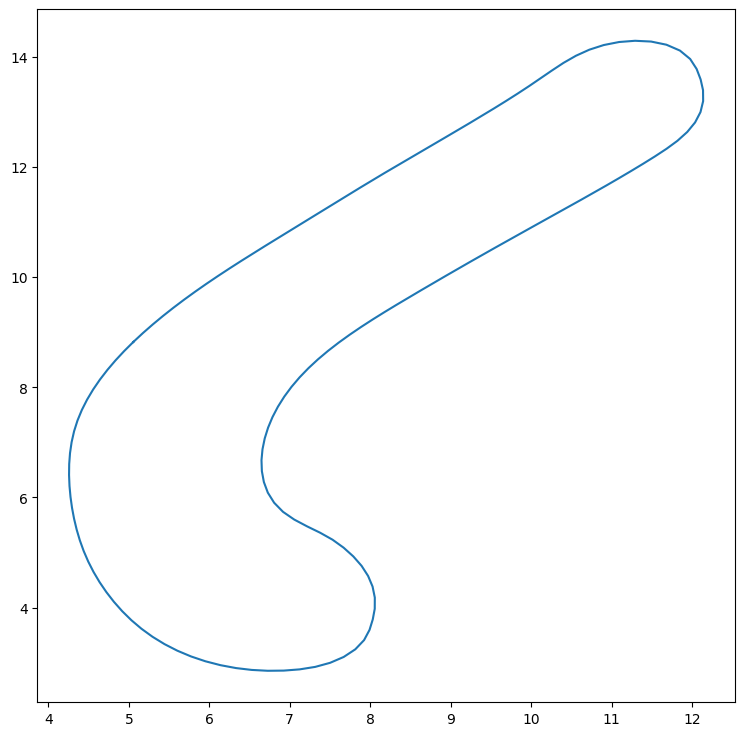

In [18]:
plt.figure(figsize=(9,9))
plt.plot(raw_data.iloc[:, 0], raw_data.iloc[:, 1])

In [19]:
# Overlay the racetrack on the map
# load map yaml
if os.path.exists(f"maps/{MAP_NAME}.png"):
    map_img_path = f"maps/{MAP_NAME}.png"
elif os.path.exists(f"maps/{MAP_NAME}.pgm"):
    map_img_path = f"maps/{MAP_NAME}.pgm"
else:
    raise Exception("Map not found!")
print(f"Using map image: {map_img_path}")

map_yaml_path = f"maps/{MAP_NAME}.yaml"
with open(map_yaml_path, 'r') as yaml_stream:
    try:
        map_metadata = yaml.safe_load(yaml_stream)
        map_resolution = map_metadata['resolution']
        origin = map_metadata['origin']
    except yaml.YAMLError as ex:
        print(ex)

# calculate map parameters
orig_x = origin[0]
orig_y = origin[1]
# ??? Should be 0
orig_s = np.sin(origin[2])
orig_c = np.cos(origin[2])

# get the distance transform
transformed_data = raw_data.copy()
transformed_data -= np.array([orig_x, orig_y, 0])
transformed_data.iloc[:, :2] /= map_resolution

raw_map_img = np.array(Image.open(map_img_path).transpose(Image.FLIP_TOP_BOTTOM))
raw_map_img = raw_map_img.astype(np.float64)


Using map image: maps/levine_race2.png


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


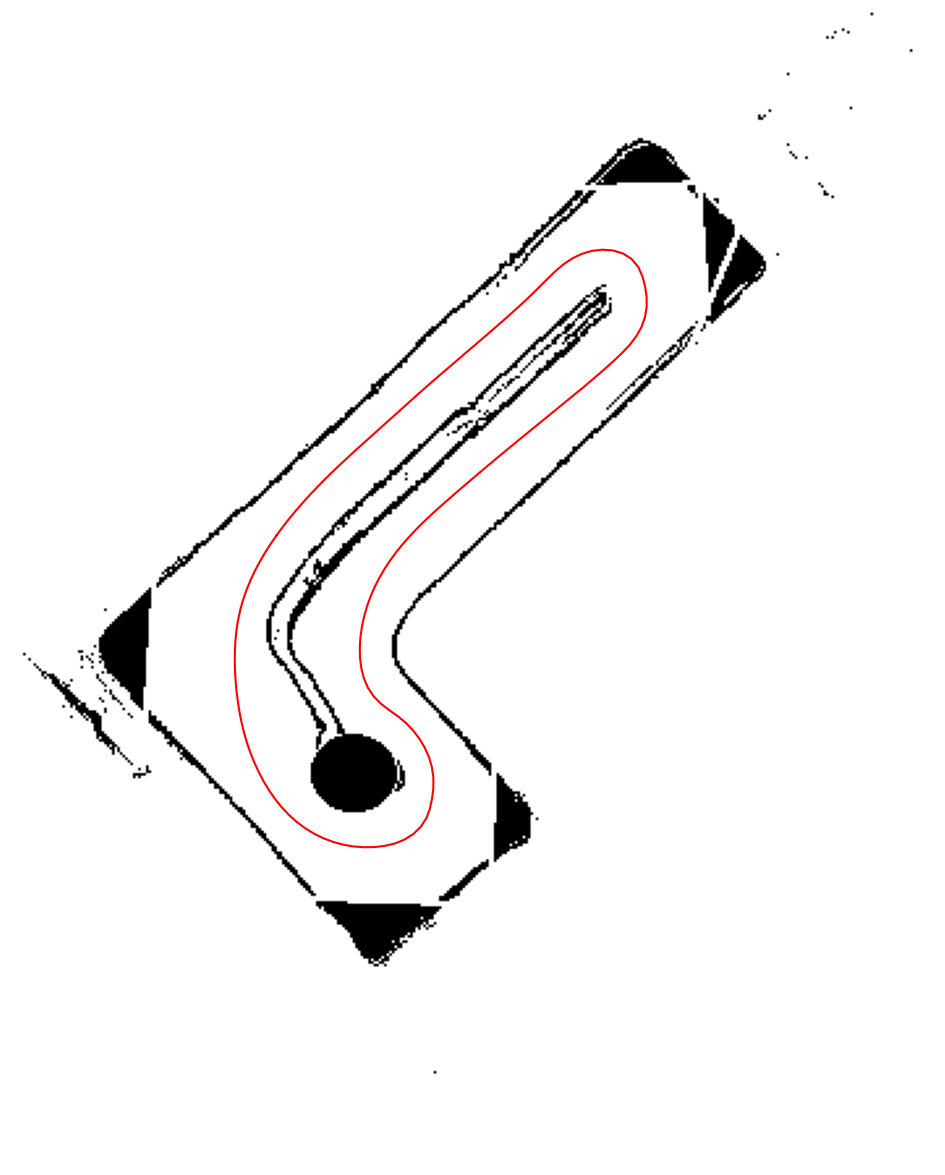

In [20]:
plt.figure(figsize=(15,15))
plt.imshow(raw_map_img, cmap='gray', origin='lower')
plt.plot(transformed_data.iloc[:, 0], transformed_data.iloc[:, 1], color='red')
# Save image without the axis
plt.axis('off')
plt.savefig(f"outputs/{MAP_NAME}_raceline.png", bbox_inches='tight', pad_inches=0)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


(-0.5, 353.5, -0.5, 441.5)

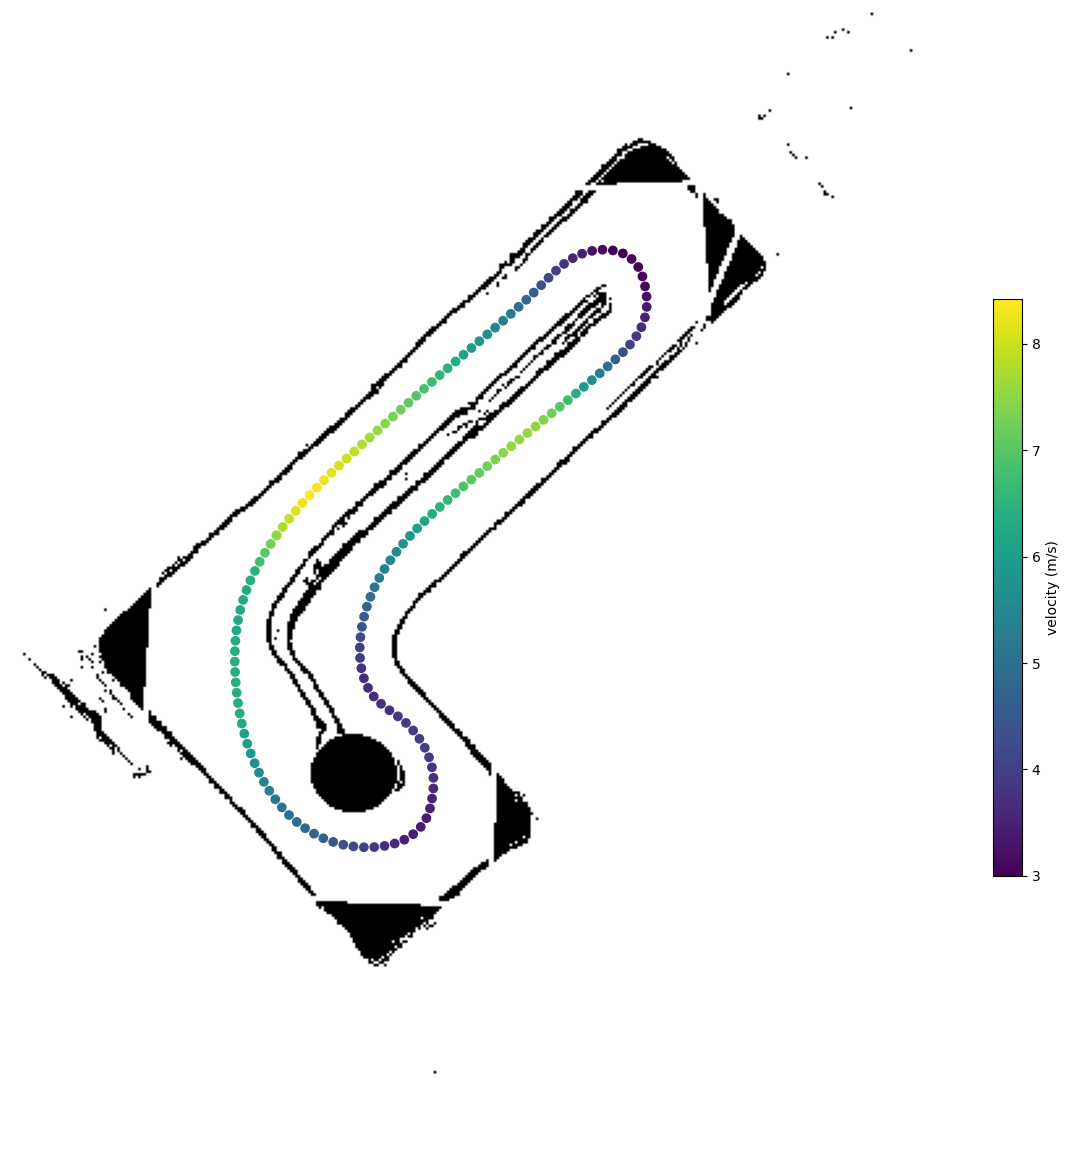

In [21]:
%matplotlib inline
plt.figure(figsize=(15,15))
plt.scatter(transformed_data.iloc[:, 0], transformed_data.iloc[:, 1], c=transformed_data.iloc[:, 2])
cbar = plt.colorbar(shrink=0.5)
cbar.set_label('velocity (m/s)')

plt.imshow(raw_map_img, cmap='gray', origin='lower')
plt.axis('off')

## (OPTIONAL) Overlay on the original map

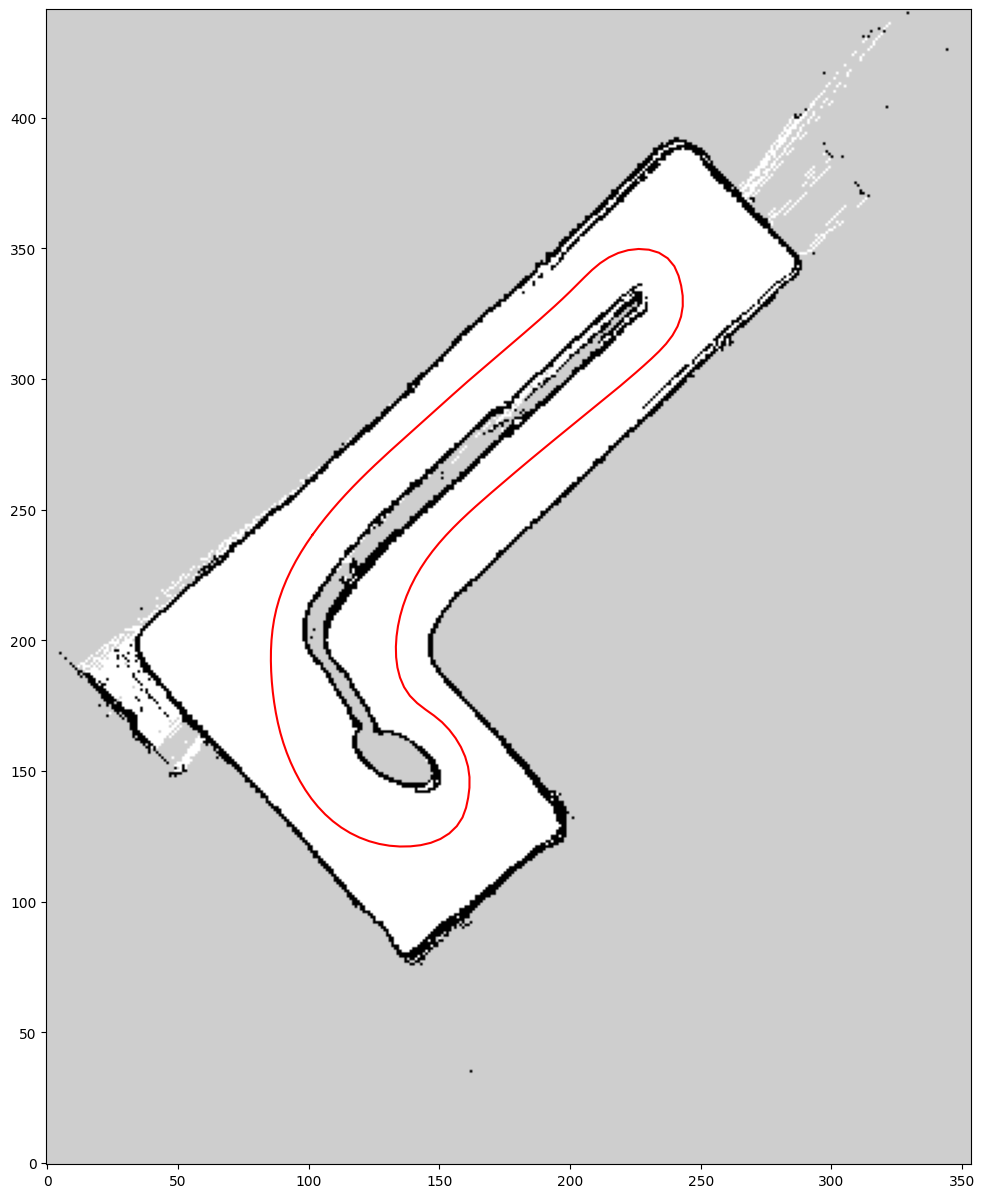

In [22]:
ORIG_MAP = f"{MAP_NAME}"
orig_map_img = np.array(Image.open(f"maps/{ORIG_MAP}.pgm").transpose(Image.FLIP_TOP_BOTTOM))
orig_map_img = orig_map_img.astype(np.float64)
plt.figure(figsize=(15,15))
plt.imshow(orig_map_img, cmap='gray', origin='lower')
plt.plot(transformed_data.iloc[:, 0], transformed_data.iloc[:, 1], color='red')

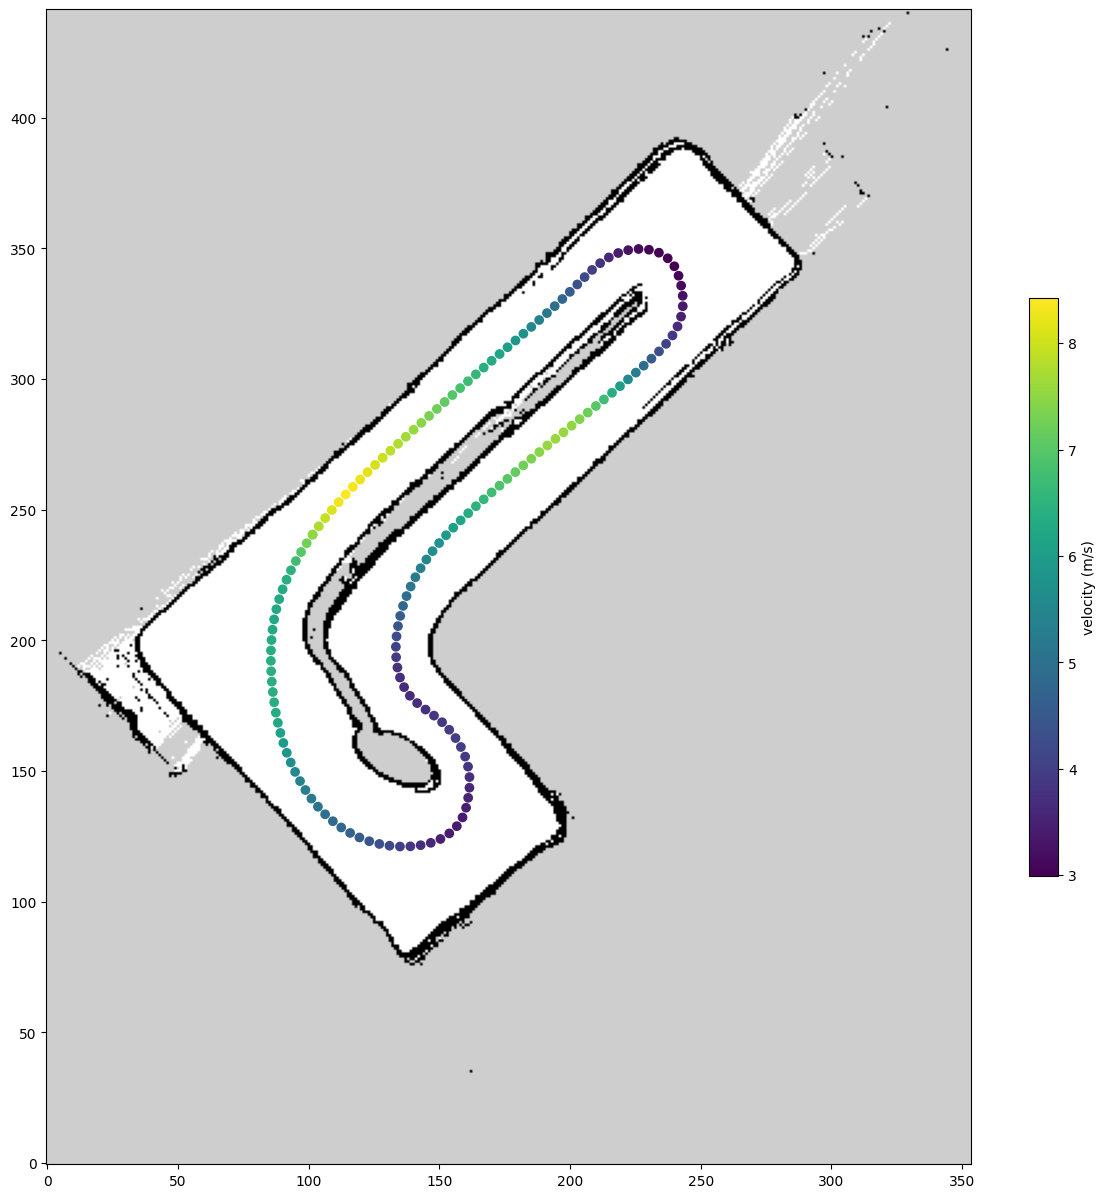

In [23]:
plt.figure(figsize=(15,15))
plt.imshow(orig_map_img, cmap='gray', origin='lower')
plt.scatter(transformed_data.iloc[:, 0], transformed_data.iloc[:, 1], c=transformed_data.iloc[:, 2])
cbar = plt.colorbar(shrink=0.5)
cbar.set_label('velocity (m/s)')

## Visualize Velocity Profile in 3D

In [24]:
raw_data_np = transformed_data.to_numpy()

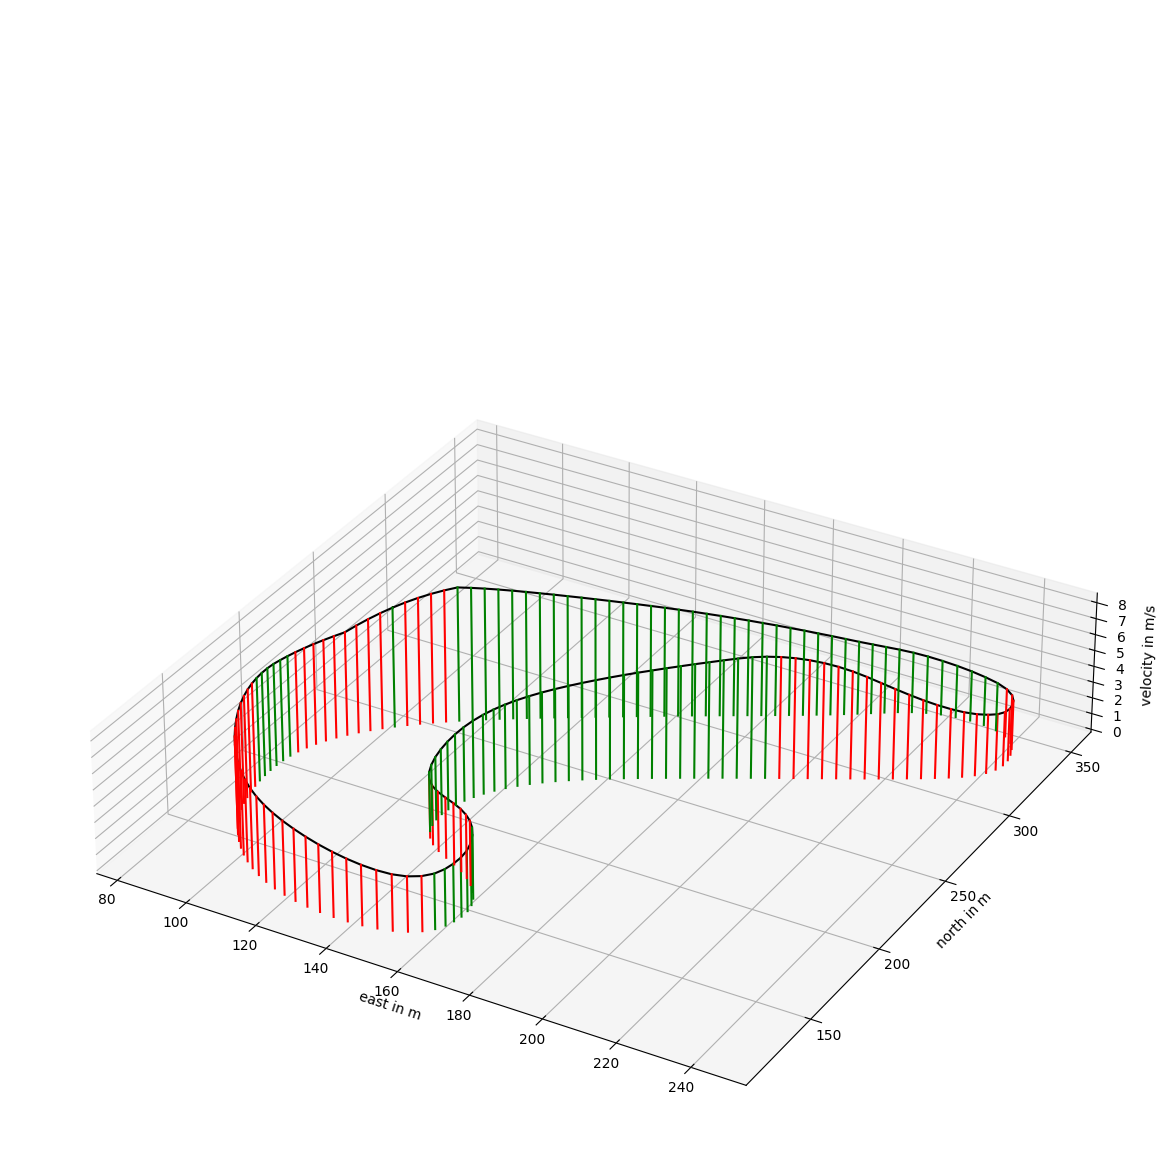

In [25]:
from mpl_toolkits.mplot3d import Axes3D
# Visualize Velocity Profile
scale_x = 1.0
scale_y = 1.0
scale_z = 0.3  # scale z axis such that it does not appear stretched

# create 3d plot

fig = plt.figure(figsize=(15, 15))
ax = fig.gca(projection='3d')

# recast get_proj function to use scaling factors for the axes
ax.get_proj = lambda: np.dot(Axes3D.get_proj(ax), np.diag([scale_x, scale_y, scale_z, 1.0]))

ax.grid()
ax.set_aspect("auto")
ax.set_xlabel("east in m")
ax.set_ylabel("north in m")

# Doesn't work
# import matplotlib
# x,y = np.mgrid[0:orig_map_img.shape[0], 0:orig_map_img.shape[1]]
# ax.plot_surface(x,y,np.sin(0*x), facecolors=matplotlib.cm.ScalarMappable(cmap='gray').to_rgba(orig_map_img))

# plot velocity profile in 3D
ax.plot(raw_data_np[:, 0], raw_data_np[:, 1], raw_data_np[:, 2], color="k")
ax.set_zlabel("velocity in m/s")

# plot vertical lines visualizing acceleration and deceleration zones
ind_stepsize = 1
cur_ind = 0
no_points_traj_vdc = np.shape(raw_data_np)[0]
prev_vel = 0
curr_vel = 0

while cur_ind < no_points_traj_vdc - 1:
	curr_vel = raw_data_np[cur_ind, 2]
	x_tmp = [raw_data_np[cur_ind, 0], raw_data_np[cur_ind, 0]]
	y_tmp = [raw_data_np[cur_ind, 1], raw_data_np[cur_ind, 1]]
	z_tmp = [0.0, curr_vel]  # plot line with height depending on velocity

	# get proper color for line depending on acceleration
	if curr_vel - prev_vel > 0.0:
		col = "g"
	elif curr_vel - prev_vel < 0.0:
		col = "r"
	else:
		col = "gray"
	
	prev_vel = curr_vel

	# plot line
	ax.plot(x_tmp, y_tmp, z_tmp, color=col)

	# increment index
	cur_ind += ind_stepsize


plt.show()

In [26]:
# Use an inline backend for 3D plotting if Qt is not available
import matplotlib
try:
    get_ipython().run_line_magic('matplotlib', 'qt')
except Exception as e:
    print('Falling back to inline backend due to:', e)
    get_ipython().run_line_magic('matplotlib', 'inline')